<a href="https://colab.research.google.com/github/2025ag05585-hue/Python-programming-Basic/blob/main/Assignment_1__group43.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This assignment is about representation learning using variants of autoencoders.  Use (1) the CIFAR10 dataset provided in Keras, after conversion to gray-level images, and (2) the MNIST handwritten gray-scale database! Rescale the datasets so that both contain 28x28 images, and normalize the intensity levels of datasets between 50 and 200. Use randomly selected 70% of the dataset as training set, 20% as the validation, and 10% as test data.

CIFAR-10
   ↓
Combine 50,000 + 10,000
   ↓
Random 70/20/10 split
   ↓
Convert RGB → Grayscale
   ↓
Resize 32×32 → 28×28
   ↓
Normalize intensity → 50–200
   ↓
Mean-center training data
   ↓
PCA / Randomized PCA
   ↓
Keep top 30 components
   ↓
Logistic Regression

In [3]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from skimage.transform import resize


Load the CIFAR-10 Dataset from the datasets available in Keras

In [2]:
# load keras dataset both training data and test data
(x_train_old,y_train_old),(x_test_old,y_test_old)=keras.datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2728s 16us/step


CIFAR-10 already comes as 50,000 training + 10,000 test = 60,000 images,Therefore it is first combining the all 60,000 images and then it is split randomly selected 70/20/10 of the dataset i.e.selected 70% of the dataset as training set, 20% as the validation, and 10% as test data.


In [7]:
x= np.concatenate((x_train_old, x_test_old), axis=0)
y = np.concatenate((y_train_old, y_test_old), axis=0)
print("Complete dataset:", x.shape)
print("Complete labels:", y.shape)

Complete dataset: (60000, 32, 32, 3)
Complete labels: (60000, 1)


The dataset is randomly split into 70% training by first split and then second split the remaining dataset(30% dataset) as  20% validation, and 10% test.since
CIFAR-10 is a 10-class classification dataset, and for proper represention of 10 classes in  training, validation, and test sets we used stratify parameter/argument of train_test_split() in scikit-learn.

In [12]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (val+test)
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: 20% val, 10% test (from temp)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp
)

print("Train:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (42000, 32, 32, 3) (42000, 1)
Validation: (12000, 32, 32, 3) (12000, 1)
Test: (6000, 32, 32, 3) (6000, 1)


In [14]:
# ============================================================
# 5. CONVERT RGB → GRAYSCALE
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.image import rgb_to_grayscale

# Convert CIFAR-10 RGB images to grayscale
x_train_gray = tf.image.rgb_to_grayscale(x_train)
x_test_gray = tf.image.rgb_to_grayscale(x_test)

# Convert TensorFlow tensors to NumPy arrays
x_train_gray = x_train_gray.numpy()
x_test_gray = x_test_gray.numpy()

print(x_train_gray.shape)
print(x_test_gray.shape)

print("\nAfter grayscale:")
print(x_train_gray.shape)



(42000, 32, 32, 1)
(6000, 32, 32, 1)

After grayscale:
(42000, 32, 32, 1)


The resize_images loop 'skimage.transform.resize()' outputs floats pixel values  in the range [0,1] by default, so after resizing you’ll need to scale intensities  to [50,200].

In [25]:
# ============================================================
# 6. RESIZE 32×32 → 28×28
# ============================================================

import numpy as np
from skimage.transform import resize

# Ensure x_val is also converted to grayscale
x_val_gray = tf.image.rgb_to_grayscale(x_val).numpy()

# The squeeze operation is handled within resize_images if needed.
# Removing explicit squeeze calls to avoid error on re-execution.

def resize_images(images, target_size=(28, 28)):
    # images: numpy array of shape (N, 32, 32) or (N, 32, 32, 1)
    # target_size: desired output size (28, 28)

    # If channel dimension exists, squeeze it out
    if images.ndim == 4 and images.shape[-1] == 1:
        images = images.squeeze(-1)

    resized = np.zeros((images.shape[0], target_size[0], target_size[1]))

    for i in range(images.shape[0]):
        resized[i] = resize(
            images[i],
            target_size,
            anti_aliasing=True
        )

    return resized

# Example usage
x_train_resized = resize_images(x_train_gray)
x_val_resized   = resize_images(x_val_gray)
x_test_resized  = resize_images(x_test_gray)

print("Train:", x_train_resized.shape)
print("Val  :", x_val_resized.shape)
print("Test :", x_test_resized.shape)


Train: (42000, 28, 28)
Val  : (12000, 28, 28)
Test : (6000, 28, 28)


In [27]:
# ============================================================
# 7. NORMALIZE INTENSITY TO RANGE 50–200
# ============================================================

def normalize_50_200(images):

    min_value = images.min()
    max_value = images.max()

    images = (
        (images - min_value)
        / (max_value - min_value)
    )

    images = images * 150 + 50

    return images


x_train_norm = normalize_50_200(x_train_resized)
x_val_norm   = normalize_50_200(x_val_resized)
x_test_norm  = normalize_50_200(x_test_resized)

print("\nIntensity range:")
print("Train:", x_train_norm.min(), x_train_norm.max())
print("Val  :", x_val_norm.min(), x_val_norm.max())
print("Test :", x_test_norm.min(), x_test_norm.max())


Intensity range:
Train: 50.0 200.0
Val  : 50.0 200.0
Test : 50.0 200.0


In [30]:
# ============================================================
# 8. FLATTEN 28×28 → 784 FEATURES
# ============================================================

x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_val_flat   = x_val_norm.reshape(x_val_norm.shape[0], -1)
x_test_flat  = x_test_norm.reshape(x_test_norm.shape[0], -1)

print("\nFlattened:")
print("Training:", x_train_flat.shape)
print("Validation:", x_val_flat.shape)
print("Test:", x_test_flat.shape)



Flattened:
Training: (42000, 784)
Validation: (12000, 784)
Test: (6000, 784)


#PCA Implementation
Standard PCA requires us to compute the covariance matrix of our dataset X= R(nxd), where d is the number of features and n is the number of data points.
 First, we need to centralize the data by subtracting the mean of each feature. Then, we use the formula above to find the covariance matrix. then perform the eigenvalue decomposition on the covariance matrix to obtain the principal components.


In [33]:
# ============================================================
# 9. MEAN-CENTER THE DATA
# ============================================================

# Calculate mean ONLY from training data

mean_vector = x_train_flat.mean(axis=0)

x_train_centered = x_train_flat - mean_vector
x_val_centered   = x_val_flat - mean_vector
x_test_centered  = x_test_flat - mean_vector

print("\nMean-centered data:")
print(x_train_centered.shape)



Mean-centered data:
(42000, 784)


To inspect the first few elements of a NumPy array,one should use array slicing, like x_train_centered[:5].The output displays the first five rows of your x_train_centered NumPy array. These are the pixel values for the first five training images after they have been:

Converted to grayscale.
Resized to 28x28 pixels.
Normalized to a range of 50-200.
Flattened from a 2D image into a 1D vector of 784 features.
Mean-centered by subtracting the mean feature value (calculated from the entire training set) from each pixel.

In [35]:
print(x_train_centered[:5])

[[-40.54739889 -40.85549841 -47.5400075  ...  -2.26778154  -9.14526982
    0.93472639]
 [-31.2646858  -22.73725111  -1.18646609 ... -13.12312368  -2.39256874
   -4.38340086]
 [-10.46036407 -10.64241318 -10.0009919  ... -11.64053064 -15.49280884
  -13.3990071 ]
 [-33.7466786  -17.29307344 -17.42596188 ...  75.65838893  75.25749128
   75.06737945]
 [ 25.30794325  24.60968766  24.53382203 ...  -7.78698922  -7.29052793
   -6.91641407]]


In [37]:
# ============================================================
# 10. PCA — KEEP TOP 30 COMPONENTS
# ============================================================

pca = PCA(
    n_components=30,
    random_state=42
)

x_train_pca = pca.fit_transform(x_train_centered)

x_val_pca = pca.transform(x_val_centered)

x_test_pca = pca.transform(x_test_centered)

print("\nPCA features:")
print("Training:", x_train_pca.shape)
print("Validation:", x_val_pca.shape)
print("Test:", x_test_pca.shape)



PCA features:
Training: (42000, 30)
Validation: (12000, 30)
Test: (6000, 30)


In [ ]:
# ============================================================
# 11. EXPLAINED VARIANCE
# ============================================================

explained_variance = pca.explained_variance_ratio_

print("\nExplained variance ratio:")
print(explained_variance)

print("\nTotal variance explained by 30 components:",
      explained_variance.sum())


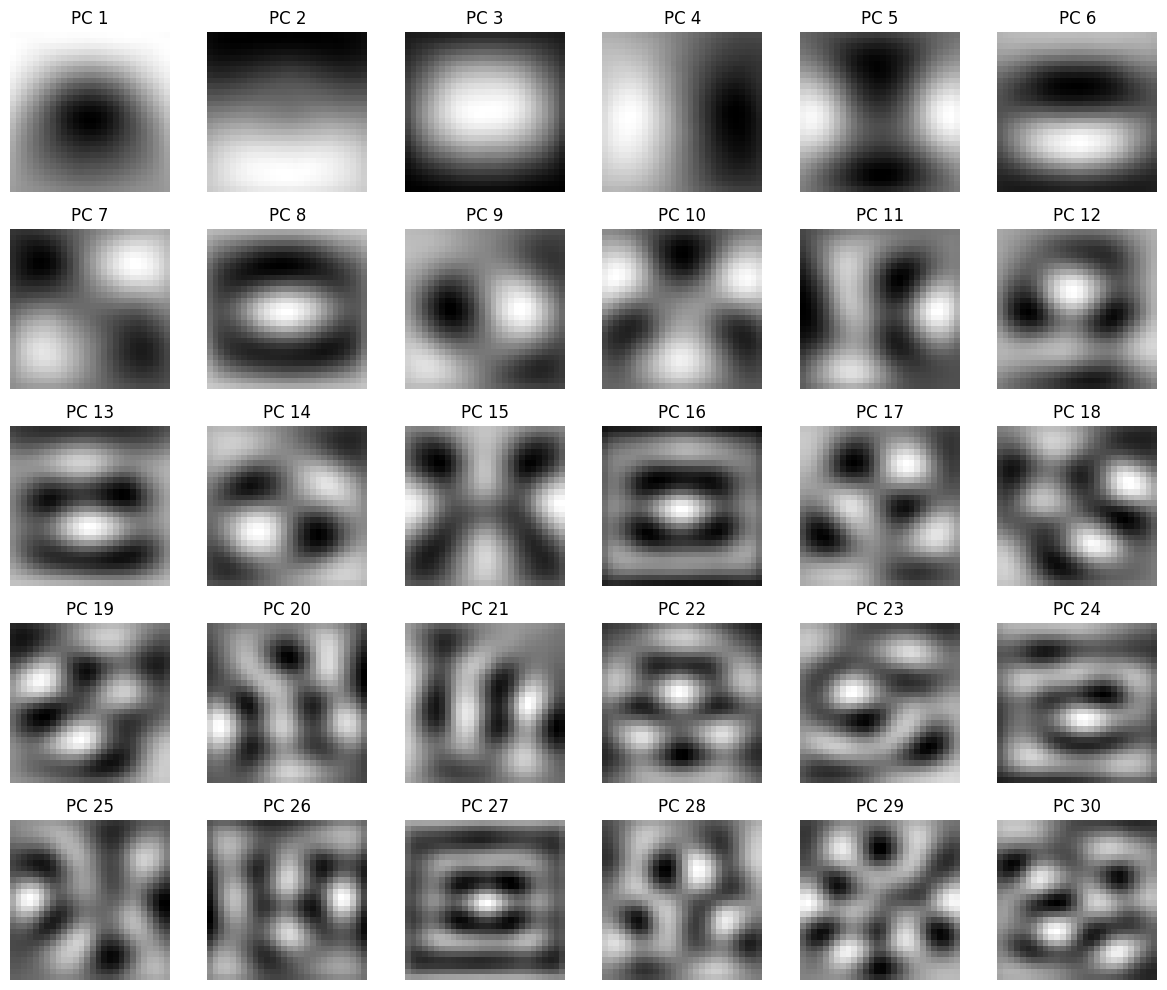

In [38]:
import matplotlib.pyplot as plt

# Each PCA component is a vector of length 28*28 = 784
components = pca.components_

fig, axes = plt.subplots(5, 6, figsize=(12, 10))  # 5 rows × 6 cols = 30 plots
axes = axes.ravel()

for i in range(30):
    comp = components[i].reshape(28, 28)  # reshape back to image
    axes[i].imshow(comp, cmap='gray')
    axes[i].set_title(f"PC {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [46]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define multinomial logistic regression
classifier = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",   # handles multiclass directly
    solver="lbfgs",              # efficient solver for multinomial
    random_state=42
)

# Train classifier on PCA features
classifier.fit(x_train_pca, y_train.ravel())

# Predict on validation and test sets
y_val_pred = classifier.predict(x_val_pca)
y_test_pred = classifier.predict(x_test_pca)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


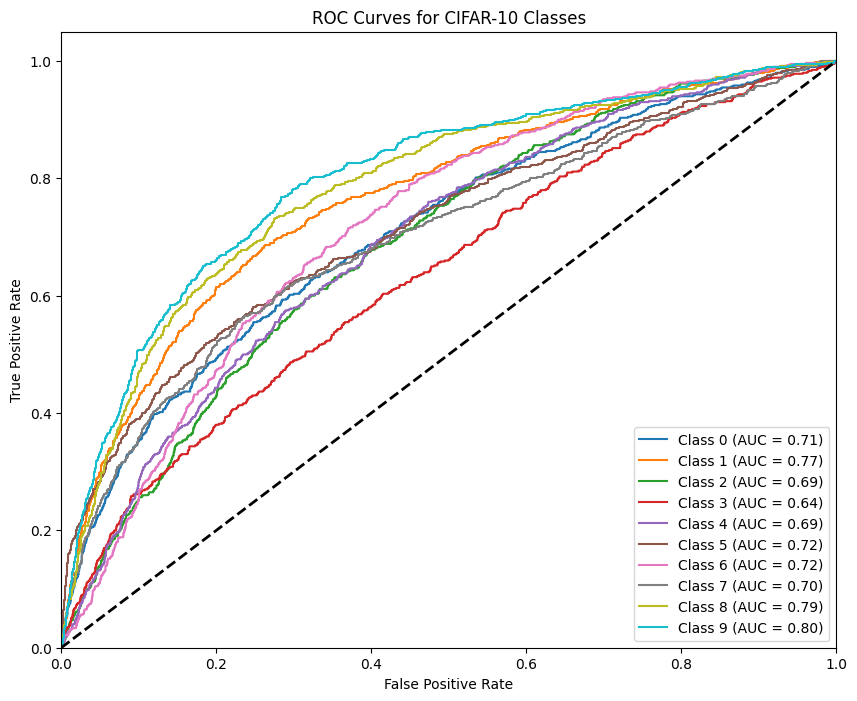

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Assume y_test contains true labels (shape: (N,1))
# and y_score contains predicted probabilities (shape: (N,10))
# y_score should come from your classifier (e.g., softmax outputs)

n_classes = 10

# Binarize labels: one-hot encoding
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# Get predicted probabilities for ROC curve
y_score = classifier.predict_proba(x_test_pca)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for CIFAR-10 Classes")
plt.legend(loc="lower right")
plt.show()


In [ ]:
 ============================================================
# 13. VALIDATION PERFORMANCE
# ============================================================

y_val_pred = classifier.predict(X_val_pca)

val_accuracy = accuracy_score(
    y_val,
    y_val_pred
)

print("\nValidation Accuracy:",
      val_accuracy)

In [ ]:
# ============================================================
# 14. TEST PERFORMANCE
# ============================================================

y_test_pred = classifier.predict(X_test_pca)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print("\nTest Accuracy:",
      test_accuracy)


In [ ]:
# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names
    )
)


In [ ]:
 ============================================================
# 16. VISUALIZE ONE ORIGINAL IMAGE
# ============================================================

plt.figure(figsize=(5, 5))

plt.imshow(
    X_test_gray[0],
    cmap="gray"
)

plt.title(
    "Original CIFAR-10 Grayscale Image"
)

plt.axis("off")

plt.show()

In [ ]:
from skimage.transform import resize

def resize_images(images):

    resized = np.zeros((images.shape[0], 28, 28))

    for i in range(images.shape[0]):
        resized[i] = resize(
            images[i],
            (28, 28),
            anti_aliasing=True
        )

    return resized


X_train_resized = resize_images(X_train_gray)
X_val_resized   = resize_images(X_val_gray)
X_test_resized  = resize_images(X_test_gray)

print("\nAfter resizing:")
print("Training:", X_train_resized.shape)
print("Validation:", X_val_resized.shape)
print("Test:", X_test_resized.shape)

# Randomized PCA

In [48]:
from sklearn.decomposition import PCA

# ============================================================
# RANDOMIZED PCA — TOP 30 COMPONENTS
# ============================================================

randomized_pca = PCA(
    n_components=30,
    svd_solver="randomized",
    random_state=42
)

# Fit ONLY on training data
x_train_rpca = randomized_pca.fit_transform(x_train_centered)

# Transform validation and test data
x_val_rpca = randomized_pca.transform(x_val_centered)
x_test_rpca = randomized_pca.transform(x_test_centered)

print("Randomized PCA:")
print("Training   :", x_train_rpca.shape)
print("Validation :", x_val_rpca.shape)
print("Test       :", x_test_rpca.shape)

# Total variance retained
print(
    "Variance explained:",
    randomized_pca.explained_variance_ratio_.sum()
)

Randomized PCA:
Training   : (42000, 30)
Validation : (12000, 30)
Test       : (6000, 30)
Variance explained: 0.8496827895226537


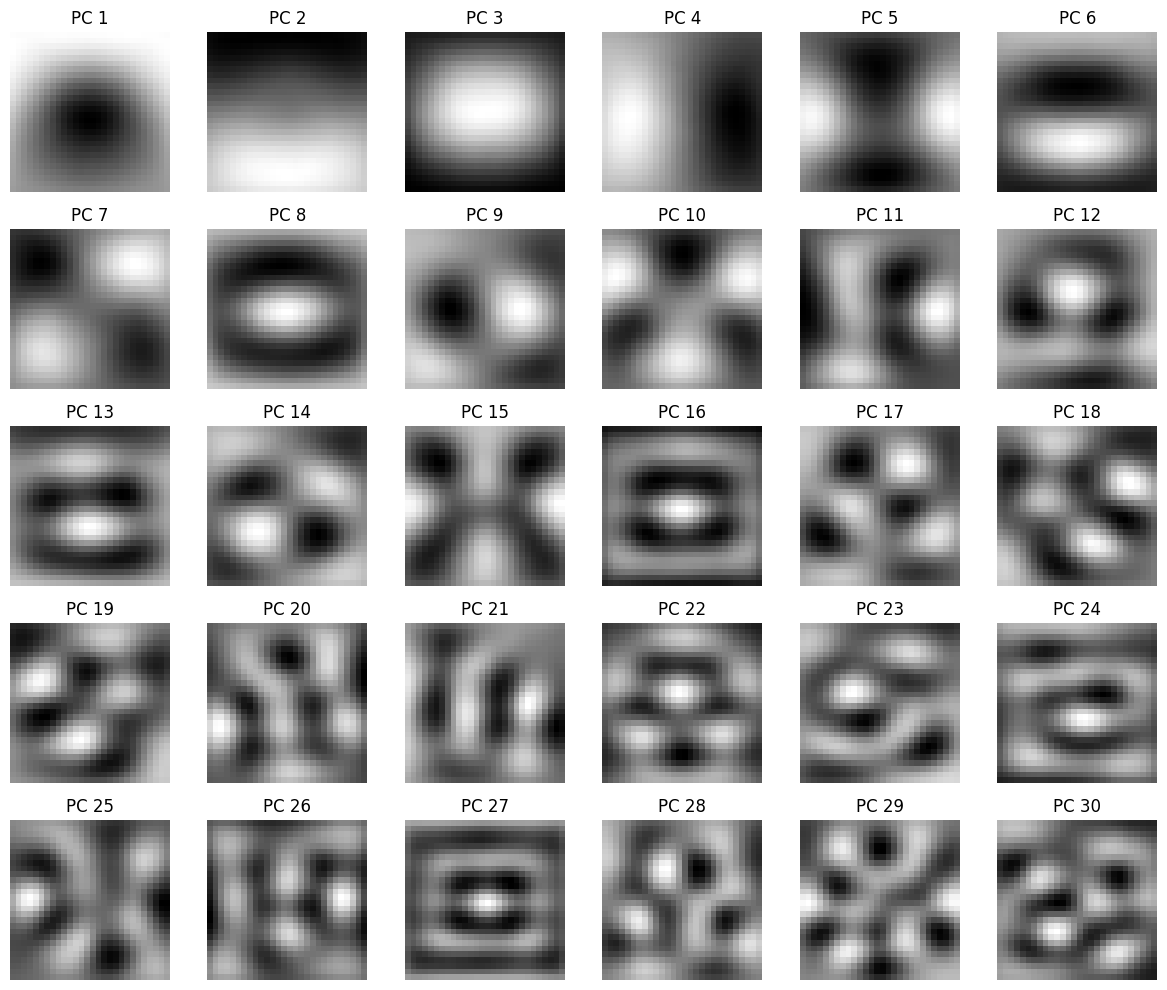

In [49]:
import matplotlib.pyplot as plt

# Get PCA components (each is a vector of length 28*28 = 784)
components = randomized_pca.components_

fig, axes = plt.subplots(5, 6, figsize=(12, 10))  # 5 rows × 6 cols = 30 plots
axes = axes.ravel()

for i in range(30):
    comp = components[i].reshape(28, 28)  # reshape back to image
    axes[i].imshow(comp, cmap='gray')
    axes[i].set_title(f"PC {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


reconstructing the images using the retained 30 PCA components and prints the average reconstruction SNR (dB) for train, validation, and test sets all together.

In [50]:
import numpy as np

def compute_snr(original, reconstructed):
    # Flatten images
    orig = original.flatten()
    recon = reconstructed.flatten()

    # Signal power
    signal_power = np.mean(orig ** 2)
    # Noise power
    noise_power = np.mean((orig - recon) ** 2)

    if noise_power == 0:
        return np.inf

    return 10 * np.log10(signal_power / noise_power)

def average_snr(original_set, reduced_set, pca_model):
    # Reconstruct from PCA space
    reconstructed = pca_model.inverse_transform(reduced_set)
    # Compute SNR for each sample
    snr_values = [compute_snr(original_set[i], reconstructed[i])
                  for i in range(original_set.shape[0])]
    return np.mean(snr_values)

# Compute average SNR for train, val, test
avg_snr_train = average_snr(x_train_centered, x_train_rpca, randomized_pca)
avg_snr_val   = average_snr(x_val_centered,   x_val_rpca,   randomized_pca)
avg_snr_test  = average_snr(x_test_centered,  x_test_rpca,  randomized_pca)

print("\nAverage Reconstruction SNR (dB):")
print("Training   :", avg_snr_train)
print("Validation :", avg_snr_val)
print("Test       :", avg_snr_test)



Average Reconstruction SNR (dB):
Training   : 8.159827934091062
Validation : 8.135925805044332
Test       : 8.170139871819332


Randomized PCA for reconstruction for train, validation, and test sets using your randomized_pca model:

In [52]:
import numpy as np
from sklearn.decomposition import PCA

# ============================================================
# RANDOMIZED PCA — TOP 30 COMPONENTS
# ============================================================
randomized_pca = PCA(
    n_components=30,
    svd_solver="randomized",
    random_state=42
)

# Fit ONLY on training data
x_train_rpca = randomized_pca.fit_transform(x_train_centered)
x_val_rpca   = randomized_pca.transform(x_val_centered)
x_test_rpca  = randomized_pca.transform(x_test_centered)

print("Randomized PCA:")
print("Training   :", x_train_rpca.shape)
print("Validation :", x_val_rpca.shape)
print("Test       :", x_test_rpca.shape)
print("Variance explained (sum):", randomized_pca.explained_variance_ratio_.sum())

Randomized PCA:
Training   : (42000, 30)
Validation : (12000, 30)
Test       : (6000, 30)
Variance explained (sum): 0.8496827895226537


# MNIST Dataset
MNIST dataset contains a total of 70,000 images of handwritten digits. These images are divided into two sets:
Training set: 60,000 images.
Test set: 10,000 images.
Each image is a grayscale image of size 28x28 pixels, and each pixel value is an integer between 0 and 255, representing the intensity of the pixel.
The MNIST dataset is stored in IDX file format, which is a simple format for vectors and multidimensional matrices of various numerical types.
The MNIST dataset can be easily accessed and used with TensorFlow through the tfds (TensorFlow Datasets) library.

In [30]:
# Load MNIST dataset
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = keras.datasets.mnist.load_data()


In [33]:
x_train_mnist[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

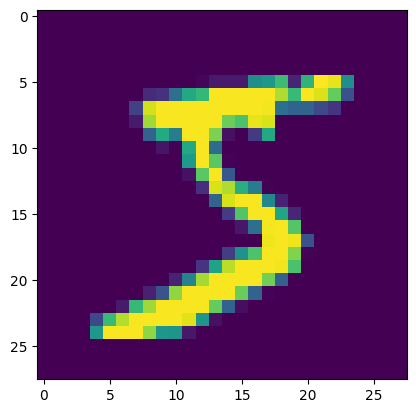

In [34]:
plt.imshow(x_train_mnist[0])

In [8]:
# Check the shape of Training Inmages of cifar10 dataset
print("CIFAR-10 training images:", x_train.shape)
print("CIFAR-10 training labels:", y_train.shape)
print("CIFAR-10 test images:", x_test.shape)
print("CIFAR-10 test labels:", y_test.shape)

CIFAR-10 training images: (50000, 32, 32, 3)
CIFAR-10 training labels: (50000, 1)
CIFAR-10 test images: (10000, 32, 32, 3)
CIFAR-10 test labels: (10000, 1)


array([[[255, 255, 255],
        [253, 253, 253],
        [253, 253, 253],
        ...,
        [253, 253, 253],
        [253, 253, 253],
        [253, 253, 253]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       ...,

       [[113, 120, 112],
        [111, 118, 111],
        [105, 112, 106],
        ...,
        [ 72,  81,  80],
        [ 72,  80,  79],
        [ 72,  80,  79]],

       [[111, 118, 110],
        [104, 111, 104],
        [ 99, 106,  98],
        ...,
        [ 68,  75,  73],
        [ 70,  76,  75],
        [ 78,  84,  82]],

       [[106, 113, 105],
        [ 99, 106,  98],
        [ 95, 102,  94],
        ...,
        [ 78,  85,  83],
        [ 79,  85,  83],
        [ 80,  86,  84]]], dtype=uint8)
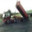

In [26]:
# Visualising the 1st image of CIFAR dataset
x_train[2]


In [13]:
y_train[0]

array([6], dtype=uint8)

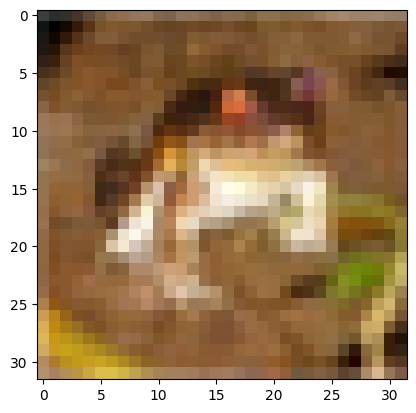

In [10]:
# To visualise
plt.imshow(x_train[0])

In [22]:
# Convert dataset into Grayscale
import numpy as np
from tensorflow.image import rgb_to_grayscale

# Convert CIFAR-10 RGB images to grayscale
x_train_gray = tf.image.rgb_to_grayscale(x_train)
x_test_gray = tf.image.rgb_to_grayscale(x_test)

# Convert TensorFlow tensors to NumPy arrays
x_train_gray = x_train_gray.numpy()
x_test_gray = x_test_gray.numpy()

print(x_train_gray.shape)
print(x_test_gray.shape)

(50000, 32, 32, 1)
(10000, 32, 32, 1)


In [23]:
x_train_gray[0]

array([[[ 61],
        [ 45],
        [ 48],
        ...,
        [137],
        [130],
        [129]],

       [[ 18],
        [  0],
        [ 10],
        ...,
        [ 94],
        [ 90],
        [ 94]],

       [[ 24],
        [  8],
        [ 31],
        ...,
        [ 90],
        [ 91],
        [ 80]],

       ...,

       [[173],
        [154],
        [156],
        ...,
        [134],
        [ 35],
        [ 38]],

       [[146],
        [128],
        [143],
        ...,
        [152],
        [ 69],
        [ 59]],

       [[150],
        [136],
        [147],
        ...,
        [188],
        [124],
        [ 99]]], dtype=uint8)

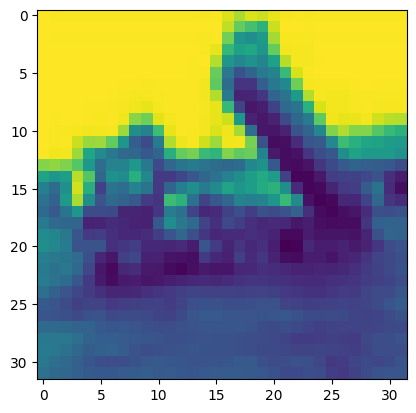

In [25]:
plt.imshow(x_train_gray[2])

In [27]:
# Resize CIFAR-10 Gray scale dataset to 28 × 28 Image
x_train_resize = tf.image.resize( x_train_gray,
    [28, 28]
).numpy()

X_test_resize = tf.image.resize(x_test_gray,
    [28, 28]
).numpy()

print(x_train_resize.shape)
print(X_test_resize.shape)

(50000, 28, 28, 1)
(10000, 28, 28, 1)
